# MarketScope AI 🇦🇺

## AI-Powered Location Intelligence Platform for Australian Businesses

### Project Objective

Many Australian businesses rely on assumptions when deciding where to expand their operations, invest their marketing budget, or target new customers.

The purpose of this project is to use data and AI to help organisations identify high-potential suburbs and make informed business decisions.

For this Proof of Concept (POC), we are focusing on selected suburbs in Victoria and building a system that can eventually provide AI-driven recommendations to businesses.

This project is being developed using a step-by-step approach, starting from data collection and progressing towards analytics, AI recommendations, and visualisation dashboards.

In [1]:
# Importing the libraries required for this project

# Pandas helps us organise and work with data in a table format.
# It allows us to clean, analyse and manipulate datasets efficiently.

import pandas as pd

print("MarketScope AI setup complete")

MarketScope AI setup complete


## Step 1: Selecting Victorian Suburbs

At this stage, we are intentionally limiting the scope of the project.

Instead of analysing all Australian suburbs, we are starting with a small set of Victorian suburbs to build a Minimum Viable Product (MVP).

This approach allows us to validate our idea first before expanding the project nationwide.

These suburbs were selected because they represent a mix of metropolitan, developing, and high-growth areas.

In [2]:
# Creating a list of Victorian suburbs that will be analysed

suburbs = [
    "Clayton",
    "Glen Waverley",
    "Box Hill",
    "Burwood",
    "Docklands",
    "Southbank",
    "Richmond",
    "Footscray",
    "Dandenong",
    "Springvale",
    "Point Cook",
    "Tarneit",
    "Werribee",
    "Geelong",
    "Ballarat"
]

# Converting the list into a dataframe
# A dataframe is simply a structured table that helps us organise our data

df = pd.DataFrame({"suburb": suburbs})

# Displaying the data

df

,suburb
0,Clayton
1,Glen Waverley
2,Box Hill
3,Burwood
4,Docklands
5,Southbank
6,Richmond
7,Footscray
8,Dandenong
9,Springvale


## Step 2: Building the Business Dataset

A suburb name by itself does not provide enough information for a business to make decisions.

To make our analysis meaningful, we need additional indicators that can influence business expansion decisions.

The following variables were selected:

- Population → Indicates the size of the potential customer base
- Median Income → Indicates purchasing power
- Age 20-39 Percentage → Represents young professionals and working-age populations
- Train Station Score → Represents accessibility
- Competitor Count → Indicates market competition
- Population Growth → Indicates future growth opportunities

These variables will eventually help us build an Opportunity Score for each suburb.

In [3]:
# Creating sample business data for each suburb

# Since this is a Proof of Concept, we are using realistic values
# to simulate business scenarios before integrating larger datasets

market_data = {

    "population": [
        21000, 43000, 14000, 16000, 16000,
        19000, 27000, 17000, 33000, 22000,
        68000, 63000, 50000, 280000, 116000
    ],

    "median_income": [
        92000, 108000, 98000, 96000, 130000,
        125000, 115000, 78000, 72000, 70000,
        112000, 95000, 90000, 85000, 80000
    ],

    "age_20_39_percentage": [
        42, 38, 40, 39, 55,
        52, 44, 35, 32, 34,
        45, 43, 40, 37, 34
    ],

    "train_station_score": [
        9, 8, 10, 7, 10,
        10, 9, 8, 9, 8,
        4, 3, 6, 9, 9
    ],

    "competitor_count": [
        8, 12, 14, 9, 25,
        20, 18, 10, 7, 8,
        5, 4, 6, 16, 12
    ],

    "population_growth": [
        12, 10, 7, 8, 15,
        14, 6, 5, 9, 10,
        18, 22, 17, 6, 4
    ]
}

In [4]:
# Combining the suburb information with the business indicators

# This creates a single dataset that will later power our AI recommendations

market_df = pd.concat(
    [df, pd.DataFrame(market_data)],
    axis=1
)

# Displaying the final dataset

market_df

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth
0,Clayton,21000,92000,42,9,8,12
1,Glen Waverley,43000,108000,38,8,12,10
2,Box Hill,14000,98000,40,10,14,7
3,Burwood,16000,96000,39,7,9,8
4,Docklands,16000,130000,55,10,25,15
5,Southbank,19000,125000,52,10,20,14
6,Richmond,27000,115000,44,9,18,6
7,Footscray,17000,78000,35,8,10,5
8,Dandenong,33000,72000,32,9,7,9
9,Springvale,22000,70000,34,8,8,10


## Why are we doing this?

Businesses should not rely on assumptions when making expansion decisions.

This dataset is the foundation of MarketScope AI.

In future stages, this data will be used to:

- Build an Opportunity Score for each suburb
- Generate AI-powered recommendations
- Create customer personas
- Build executive dashboards
- Support strategic business decisions

In [5]:
# Saving the dataset as a CSV file

# This allows us to reuse the data in future stages
# without recreating it every time

market_df.to_csv("market_scope_vic_data.csv", index=False)
from google.colab import files
files.download ("market_scope_vic_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 3: Building the Opportunity Score Engine

The data collected so far contains values that are measured differently.

For example, population is measured in thousands, while population growth is measured in percentages.

To compare these variables fairly, we first need to standardise them to the same scale.

This process is called normalisation.

Once the data is normalised, we will assign weights to each variable based on its business importance and calculate an overall Opportunity Score.

In [6]:
# Importing MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

# Creating a copy of our dataset

score_df = market_df.copy()

# Selecting the columns that will contribute to the Opportunity Score

columns_to_scale = [
    "population",
    "median_income",
    "age_20_39_percentage",
    "train_station_score",
    "population_growth"
]

# Applying Min-Max scaling

scaler = MinMaxScaler()

score_df[columns_to_scale] = scaler.fit_transform(
    score_df[columns_to_scale]
)

score_df.head()

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth
0,Clayton,0.026316,0.366667,0.434783,0.857143,8,0.444444
1,Glen Waverley,0.109023,0.633333,0.260870,0.714286,12,0.333333
2,Box Hill,0.000000,0.466667,0.347826,1.000000,14,0.166667
3,Burwood,0.007519,0.433333,0.304348,0.571429,9,0.222222
4,Docklands,0.007519,1.000000,1.000000,1.000000,25,0.611111


## Handling Competitor Density Separately

Competitor density is treated differently because its relationship with business opportunity is not linear.

Too few competitors may indicate low market demand, while too many competitors may indicate market saturation.

Instead of assuming that a lower value is always better, we will create a Competitor Score that rewards suburbs with a balanced level of competition.

In [7]:
# Creating a business rule for competitor density

def calculate_competitor_score(count):

    if count <= 2:
        return 4

    elif count <= 6:
        return 8

    elif count <= 12:
        return 10

    elif count <= 18:
        return 7

    else:
        return 4


# Creating a new column

score_df["competitor_score"] = score_df[
    "competitor_count"
].apply(calculate_competitor_score)

score_df[["suburb", "competitor_count", "competitor_score"]]

,suburb,competitor_count,competitor_score
0,Clayton,8,10
1,Glen Waverley,12,10
2,Box Hill,14,7
3,Burwood,9,10
4,Docklands,25,4
5,Southbank,20,4
6,Richmond,18,7
7,Footscray,10,10
8,Dandenong,7,10
9,Springvale,8,10


## Assigning Business Weights

Not every variable has the same importance.

The weights below were chosen based on business assumptions.

Population and income are given the highest importance because they directly influence market size and purchasing power.

Population growth indicates future opportunities.

Accessibility and age demographics help identify target customers.

In [8]:
weights = {

    "population": 0.23,

    "median_income": 0.23,

    "population_growth": 0.18,

    "train_station_score": 0.14,

    "age_20_39_percentage": 0.10,

    "competitor_score": 0.12

}

In [9]:
score_df["opportunity_score"] = (

    score_df["population"] * weights["population"]

    + score_df["median_income"] * weights["median_income"]

    + score_df["population_growth"] * weights["population_growth"]

    + score_df["train_station_score"] * weights["train_station_score"]

    + score_df["age_20_39_percentage"] * weights["age_20_39_percentage"]

    + (score_df["competitor_score"] / 10) * weights["competitor_score"]

)

In [10]:
score_df["opportunity_score"] = (

    score_df["opportunity_score"] * 100

).round(2)

In [11]:
score_df = score_df.sort_values(

    by="opportunity_score",

    ascending=False

)

score_df[["suburb", "opportunity_score"]]

,suburb,opportunity_score
4,Docklands,62.97
5,Southbank,59.01
13,Geelong,53.32
10,Point Cook,52.02
1,Glen Waverley,47.68
11,Tarneit,46.20
6,Richmond,45.99
0,Clayton,45.39
12,Werribee,42.86
2,Box Hill,39.61


In [12]:
# Saving the final dataset

score_df.to_csv(
    "market_scope_scored_data.csv",
    index=False
)

# MarketScope AI - Exploratory Data Analysis (EDA)

## Objective

The purpose of this stage is to identify patterns and trends within the suburb dataset.

Rather than jumping straight to AI recommendations, we first want to understand what the data is telling us.

These insights will later support data-driven recommendations for businesses.

In [13]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt

# Loading our dataset

score_df = pd.read_csv("market_scope_scored_data.csv")

score_df.head()

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth,competitor_score,opportunity_score
0,Docklands,0.007519,1.000000,1.000000,1.000000,25,0.611111,4,62.97
1,Southbank,0.018797,0.916667,0.869565,1.000000,20,0.555556,4,59.01
2,Geelong,1.000000,0.250000,0.217391,0.857143,16,0.111111,7,53.32
3,Point Cook,0.203008,0.700000,0.565217,0.142857,5,0.777778,8,52.02
4,Glen Waverley,0.109023,0.633333,0.260870,0.714286,12,0.333333,10,47.68


## Identifying Top Performing Suburbs

This analysis helps us understand which suburbs have the highest overall business potential based on our Opportunity Score.

In [14]:
top_suburbs = score_df[
    ["suburb", "opportunity_score"]
].sort_values(
    by="opportunity_score",
    ascending=False
)

top_suburbs

,suburb,opportunity_score
0,Docklands,62.97
1,Southbank,59.01
2,Geelong,53.32
3,Point Cook,52.02
4,Glen Waverley,47.68
5,Tarneit,46.20
6,Richmond,45.99
7,Clayton,45.39
8,Werribee,42.86
9,Box Hill,39.61


## Analysing Purchasing Power

Median income is an important indicator because it represents the spending capacity of residents.

In [15]:
income_df = score_df[
    ["suburb", "median_income"]
].sort_values(
    by="median_income",
    ascending=False
)

income_df

,suburb,median_income
0,Docklands,1.000000
1,Southbank,0.916667
6,Richmond,0.750000
3,Point Cook,0.700000
4,Glen Waverley,0.633333
9,Box Hill,0.466667
11,Burwood,0.433333
5,Tarneit,0.416667
7,Clayton,0.366667
8,Werribee,0.333333


## Analysing Young Professional Density

Young professionals are an important customer segment for many industries such as health insurance, banking, telecommunications and retail.

In [16]:
young_professionals = score_df[
    ["suburb", "age_20_39_percentage"]
].sort_values(
    by="age_20_39_percentage",
    ascending=False
)

young_professionals

,suburb,age_20_39_percentage
0,Docklands,1.000000
1,Southbank,0.869565
3,Point Cook,0.565217
6,Richmond,0.521739
5,Tarneit,0.478261
7,Clayton,0.434783
8,Werribee,0.347826
9,Box Hill,0.347826
11,Burwood,0.304348
4,Glen Waverley,0.260870


In [17]:
# ===========================================================
# Importing the libraries required for data analysis
# ===========================================================

# Pandas is used to work with tables and datasets.
# Matplotlib helps us create charts.
# Seaborn creates cleaner and more informative visualisations.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a clean visual style for all charts

sns.set_style("whitegrid")

## Loading the Processed Dataset

The Opportunity Score has already been calculated in the previous notebook.

In this notebook, we will focus on analysing the results rather than creating them again.

In [18]:
# ===========================================================
# Loading the processed dataset
# ===========================================================

score_df = pd.read_csv("market_scope_scored_data.csv")

# Displaying the first five rows

score_df.head()

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth,competitor_score,opportunity_score
0,Docklands,0.007519,1.000000,1.000000,1.000000,25,0.611111,4,62.97
1,Southbank,0.018797,0.916667,0.869565,1.000000,20,0.555556,4,59.01
2,Geelong,1.000000,0.250000,0.217391,0.857143,16,0.111111,7,53.32
3,Point Cook,0.203008,0.700000,0.565217,0.142857,5,0.777778,8,52.02
4,Glen Waverley,0.109023,0.633333,0.260870,0.714286,12,0.333333,10,47.68


## Business Question 1

### Which suburbs currently have the highest Opportunity Scores?

This analysis helps identify suburbs that provide the strongest overall potential for business expansion based on our scoring framework.

In [19]:
# Selecting the top performing suburbs

top_suburbs = score_df.sort_values(
    by="opportunity_score",
    ascending=False
)

top_suburbs[
    ["suburb", "opportunity_score"]
]

,suburb,opportunity_score
0,Docklands,62.97
1,Southbank,59.01
2,Geelong,53.32
3,Point Cook,52.02
4,Glen Waverley,47.68
5,Tarneit,46.20
6,Richmond,45.99
7,Clayton,45.39
8,Werribee,42.86
9,Box Hill,39.61


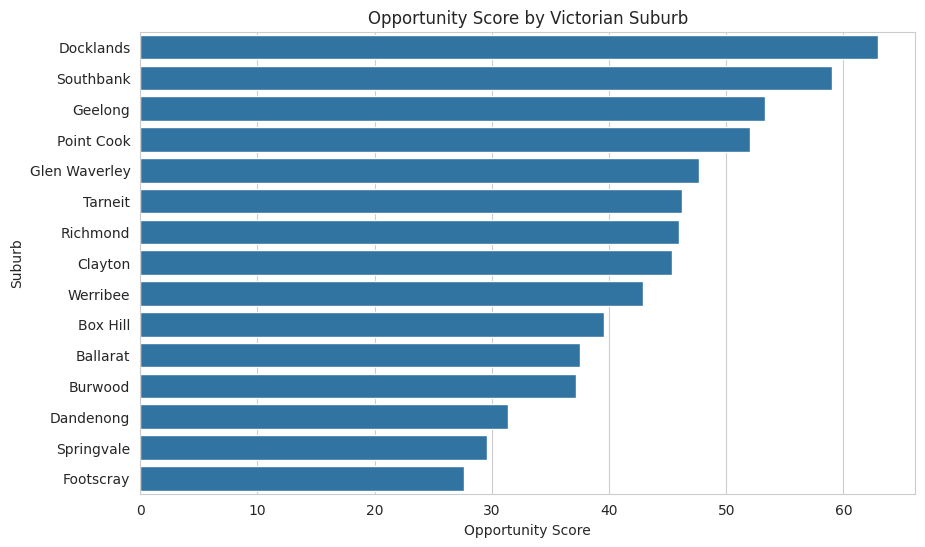

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_suburbs,
    x="opportunity_score",
    y="suburb"
)

plt.title("Opportunity Score by Victorian Suburb")

plt.xlabel("Opportunity Score")

plt.ylabel("Suburb")

plt.show()

## Business Interpretation

### Observation

Southbank, Docklands and Geelong achieved some of the highest Opportunity Scores.

### Insight

These suburbs combine favourable demographic characteristics, strong accessibility and healthy population growth, making them attractive locations for business expansion.

### Recommendation

Businesses targeting working professionals and growing communities should prioritise these suburbs when evaluating future expansion opportunities.

# Business Question 2

## Which suburbs have the highest purchasing power?

Household income is an important indicator when deciding where to introduce premium products or services.

Higher income generally suggests greater spending capacity, making these suburbs attractive for businesses targeting premium customers.

/tmp/ipykernel_552/3905995859.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


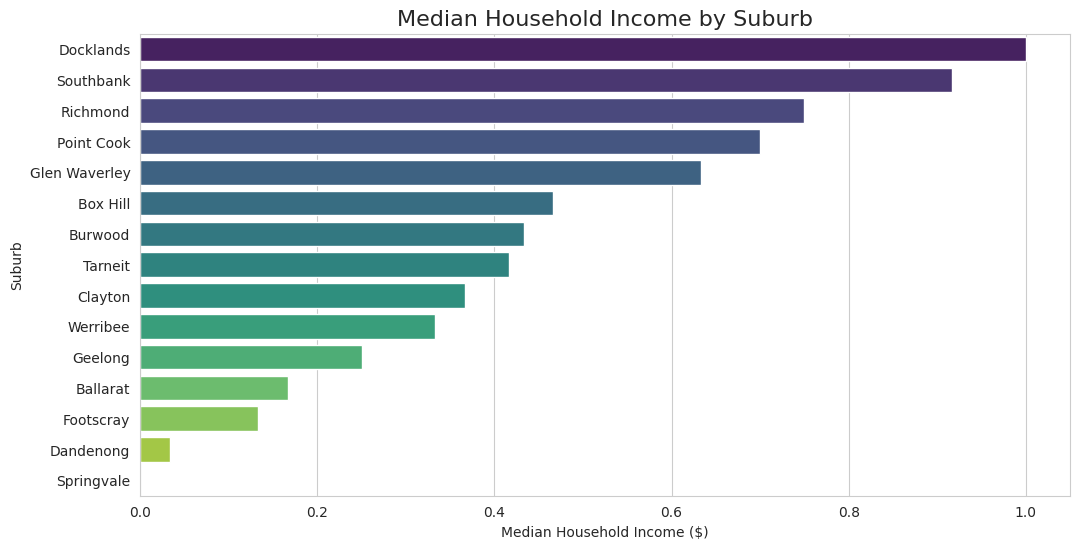

In [21]:
# ===========================================================
# Purchasing Power Analysis
# ===========================================================

income_df = score_df.sort_values(
    by="median_income",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=income_df,
    x="median_income",
    y="suburb",
    palette="viridis"
)

plt.title("Median Household Income by Suburb", fontsize=16)

plt.xlabel("Median Household Income ($)")

plt.ylabel("Suburb")

plt.show()

### Observation

Docklands, Southbank and Richmond have the highest household incomes among the selected suburbs.

### Insight

Residents in these suburbs are likely to have greater purchasing power, making them attractive markets for premium products and services.

### Business Recommendation

Businesses offering premium healthcare, banking, insurance, luxury retail or technology products should prioritise these suburbs.

# Business Question 3

## Which suburbs provide the largest customer base?

Population size directly affects the number of potential customers available within a suburb.

/tmp/ipykernel_552/2653229311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


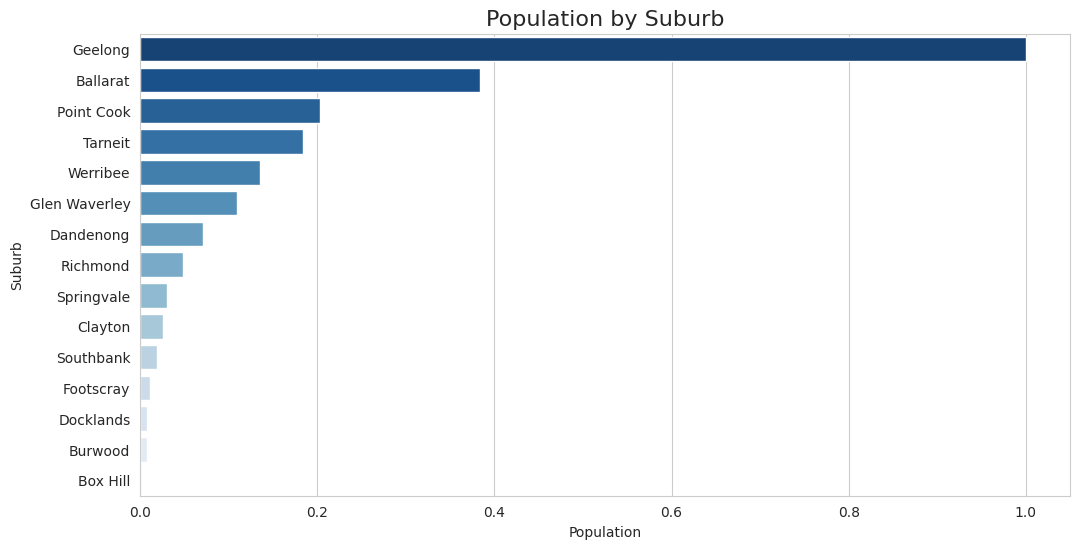

In [22]:
population_df = score_df.sort_values(
    by="population",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=population_df,
    x="population",
    y="suburb",
    palette="Blues_r"
)

plt.title("Population by Suburb", fontsize=16)

plt.xlabel("Population")

plt.ylabel("Suburb")

plt.show()

### Observation

Geelong and Ballarat have significantly larger populations than many metropolitan suburbs.

### Insight

Large populations provide businesses with a broader customer base, although population alone should not determine expansion decisions.

### Business Recommendation

Businesses with high-volume customer models such as supermarkets, telecommunications providers and retail chains should consider these locations alongside other indicators.

/tmp/ipykernel_552/60952322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


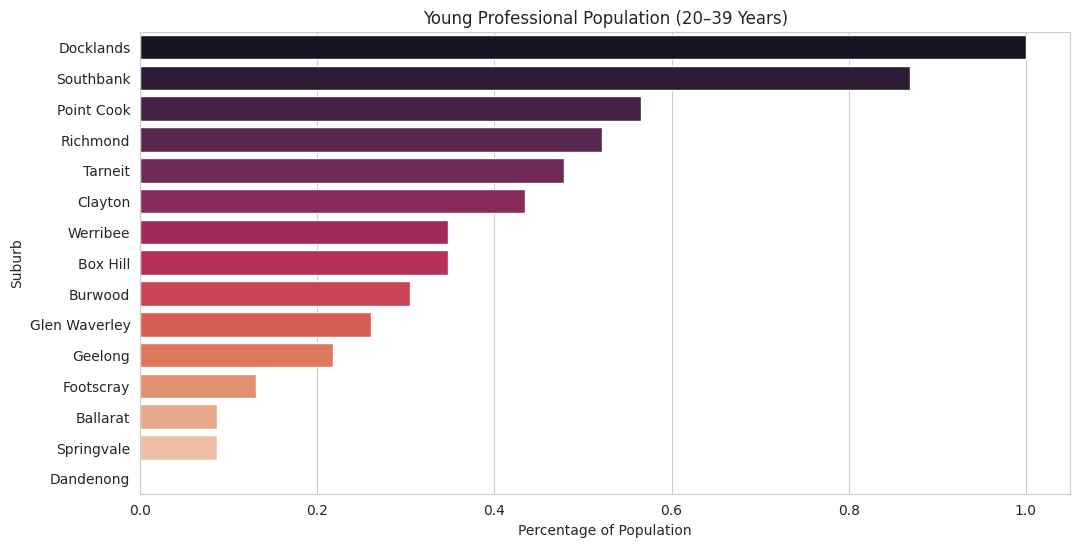

In [23]:
young_df = score_df.sort_values(
    by="age_20_39_percentage",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=young_df,
    x="age_20_39_percentage",
    y="suburb",
    palette="rocket"
)

plt.title("Young Professional Population (20–39 Years)")

plt.xlabel("Percentage of Population")

plt.ylabel("Suburb")

plt.show()

### Observation

Docklands, Southbank and Point Cook have the highest proportion of young professionals.

### Insight

Young professionals are key customers for industries such as banking, insurance, telecommunications and fitness.

### Business Recommendation

Organisations targeting working-age professionals should focus marketing campaigns within these suburbs.

/tmp/ipykernel_552/2192102425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


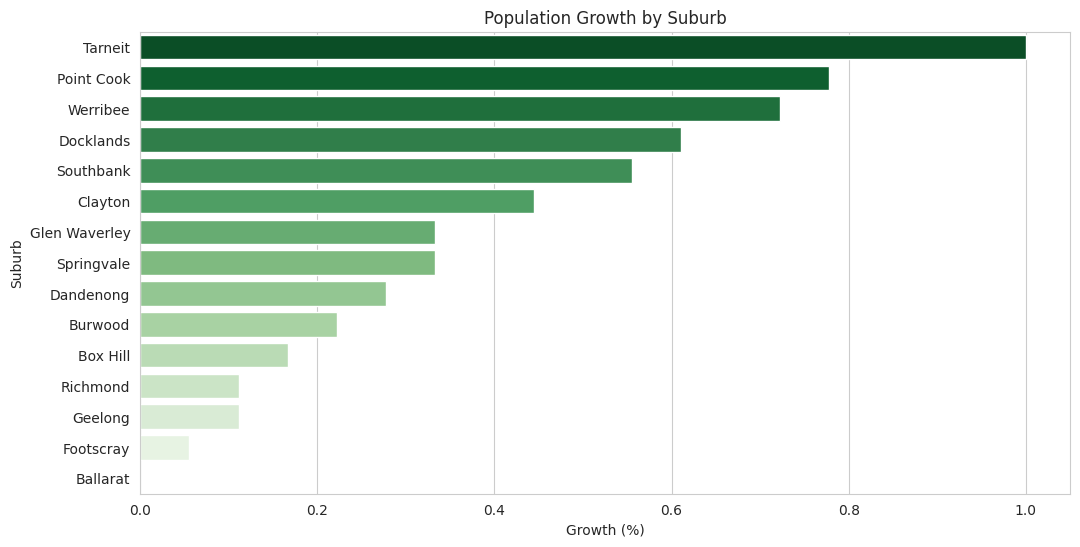

In [24]:
growth_df = score_df.sort_values(
    by="population_growth",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=growth_df,
    x="population_growth",
    y="suburb",
    palette="Greens_r"
)

plt.title("Population Growth by Suburb")

plt.xlabel("Growth (%)")

plt.ylabel("Suburb")

plt.show()

### Observation

Tarneit, Point Cook and Werribee show the highest population growth.

### Insight

Rapid population growth often indicates increasing demand for retail, healthcare, education and other essential services.

### Business Recommendation

Businesses seeking long-term expansion opportunities should monitor these suburbs closely.

/tmp/ipykernel_552/186224303.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


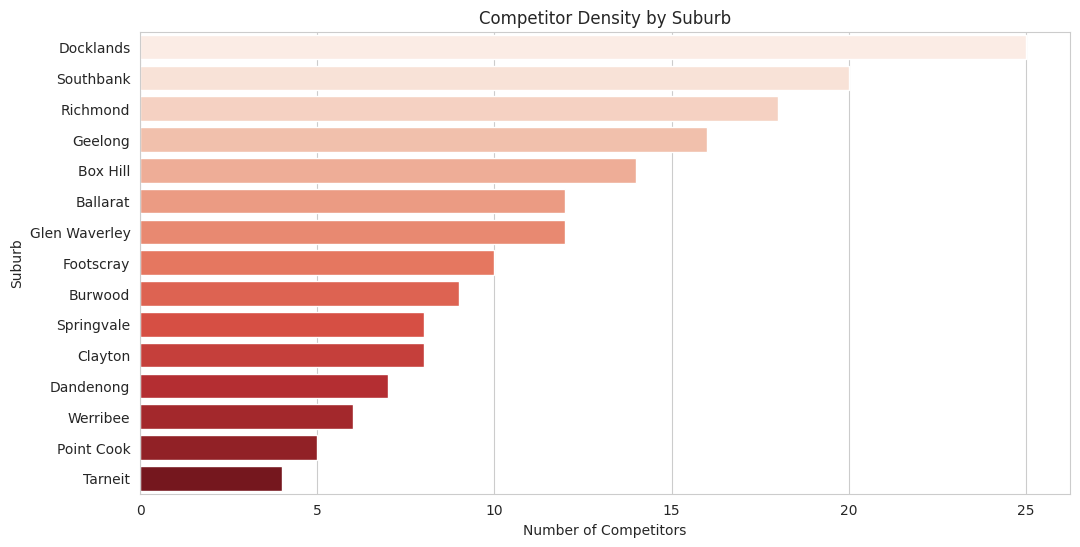

In [25]:
competition_df = score_df.sort_values(
    by="competitor_count",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=competition_df,
    x="competitor_count",
    y="suburb",
    palette="Reds"
)

plt.title("Competitor Density by Suburb")

plt.xlabel("Number of Competitors")

plt.ylabel("Suburb")

plt.show()

### Observation

Docklands and Southbank have the highest competitor density.

### Insight

High competition suggests strong market demand but also increases the difficulty of capturing market share.

### Business Recommendation

Businesses entering these suburbs should differentiate through pricing, customer experience or specialised offerings.

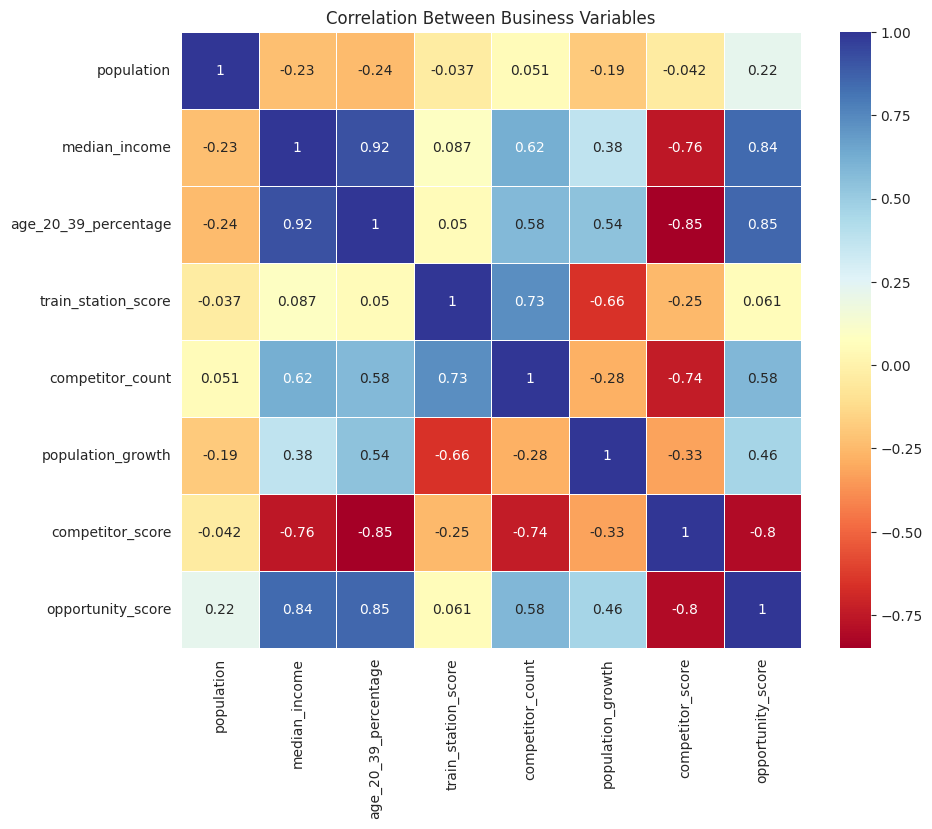

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    score_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="RdYlBu",
    linewidths=0.5
)

plt.title("Correlation Between Business Variables")

plt.show()

### Why is this important?

The heatmap helps identify relationships between business variables.

For example, it allows us to determine whether higher income tends to coincide with higher Opportunity Scores or whether population growth has a stronger influence than accessibility.

These relationships help validate our scoring framework.

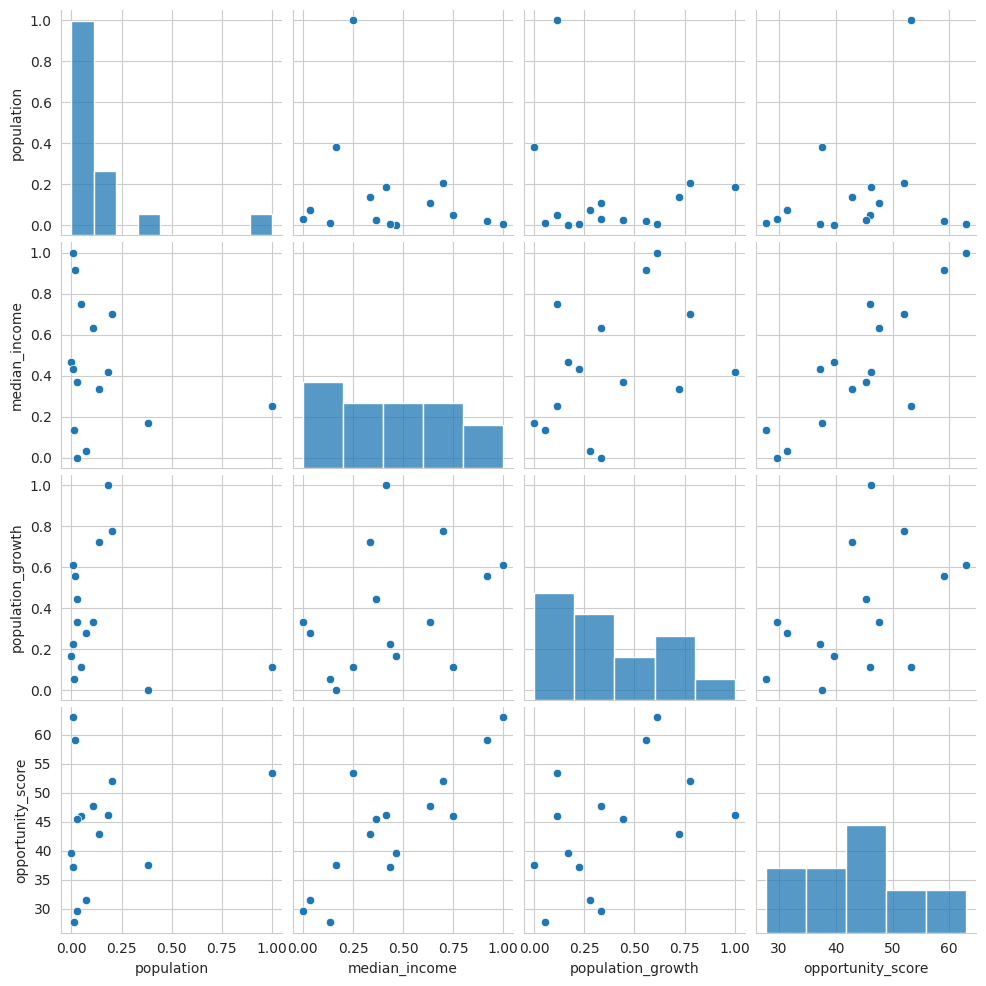

In [27]:
sns.pairplot(
    score_df[
        [
            "population",
            "median_income",
            "population_growth",
            "opportunity_score"
        ]
    ]
)

plt.show()

In [28]:
executive_summary = score_df[[
    "suburb",
    "population",
    "median_income",
    "population_growth",
    "competitor_count",
    "opportunity_score"
]].sort_values(
    by="opportunity_score",
    ascending=False
)

executive_summary

,suburb,population,median_income,population_growth,competitor_count,opportunity_score
0,Docklands,0.007519,1.000000,0.611111,25,62.97
1,Southbank,0.018797,0.916667,0.555556,20,59.01
2,Geelong,1.000000,0.250000,0.111111,16,53.32
3,Point Cook,0.203008,0.700000,0.777778,5,52.02
4,Glen Waverley,0.109023,0.633333,0.333333,12,47.68
5,Tarneit,0.184211,0.416667,1.000000,4,46.20
6,Richmond,0.048872,0.750000,0.111111,18,45.99
7,Clayton,0.026316,0.366667,0.444444,8,45.39
8,Werribee,0.135338,0.333333,0.722222,6,42.86
9,Box Hill,0.000000,0.466667,0.166667,14,39.61


In [29]:
top5 = executive_summary.head(5)

top5.style.background_gradient(cmap="Greens")

,suburb,population,median_income,population_growth,competitor_count,opportunity_score
0,Docklands,0.007519,1.000000,0.611111,25,62.970000
1,Southbank,0.018797,0.916667,0.555556,20,59.010000
2,Geelong,1.000000,0.250000,0.111111,16,53.320000
3,Point Cook,0.203008,0.700000,0.777778,5,52.020000
4,Glen Waverley,0.109023,0.633333,0.333333,12,47.680000


Load Data

In [30]:
import pandas as pd
import numpy as np

score_df = pd.read_csv("market_scope_scored_data.csv")

score_df.head()

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth,competitor_score,opportunity_score
0,Docklands,0.007519,1.000000,1.000000,1.000000,25,0.611111,4,62.97
1,Southbank,0.018797,0.916667,0.869565,1.000000,20,0.555556,4,59.01
2,Geelong,1.000000,0.250000,0.217391,0.857143,16,0.111111,7,53.32
3,Point Cook,0.203008,0.700000,0.565217,0.142857,5,0.777778,8,52.02
4,Glen Waverley,0.109023,0.633333,0.260870,0.714286,12,0.333333,10,47.68


Create Risk Score

In [31]:
def calculate_risk_score(row):

    risk = 0

    # High competition increases risk
    if row["competitor_count"] > 15:
        risk += 4

    elif row["competitor_count"] > 10:
        risk += 2

    # Low growth increases risk
    if row["population_growth"] < 2:
        risk += 3

    elif row["population_growth"] < 5:
        risk += 1

    # Poor accessibility increases risk
    if row["train_station_score"] < 5:
        risk += 3

    return risk

Apply Risk Score

In [32]:
score_df["risk_score"] = score_df.apply(
    calculate_risk_score,
    axis=1
)

score_df[
    ["suburb","opportunity_score","risk_score"]
].head(12)

,suburb,opportunity_score,risk_score
0,Docklands,62.97,10
1,Southbank,59.01,10
2,Geelong,53.32,10
3,Point Cook,52.02,6
4,Glen Waverley,47.68,8
5,Tarneit,46.20,6
6,Richmond,45.99,10
7,Clayton,45.39,6
8,Werribee,42.86,6
9,Box Hill,39.61,8


Recommendation Categories

In [33]:
def classify_suburb(row):

    if (
        row["opportunity_score"] >= 50
        and row["risk_score"] <= 6
    ):
        return "High Priority"

    elif (
        row["opportunity_score"] >= 45
    ):
        return "Medium Priority"

    else:
        return "Low Priority"

Apply Classification

In [34]:
score_df["recommendation"] = score_df.apply(
    classify_suburb,
    axis=1
)

score_df[
    [
        "suburb",
        "opportunity_score",
        "risk_score",
        "recommendation"
    ]
]

,suburb,opportunity_score,risk_score,recommendation
0,Docklands,62.97,10,Medium Priority
1,Southbank,59.01,10,Medium Priority
2,Geelong,53.32,10,Medium Priority
3,Point Cook,52.02,6,High Priority
4,Glen Waverley,47.68,8,Medium Priority
5,Tarneit,46.20,6,Medium Priority
6,Richmond,45.99,10,Medium Priority
7,Clayton,45.39,6,Medium Priority
8,Werribee,42.86,6,Low Priority
9,Box Hill,39.61,8,Low Priority


Create Business Explanation

In [35]:
def generate_reason(row):

    reasons = []

    if row["median_income"] > score_df["median_income"].median():
        reasons.append("strong purchasing power")

    if row["population_growth"] > score_df["population_growth"].median():
        reasons.append("high population growth")

    if row["train_station_score"] >= 8:
        reasons.append("excellent accessibility")

    if row["age_20_39_percentage"] > score_df["age_20_39_percentage"].median():
        reasons.append("large young professional population")

    if len(reasons) == 0:
        reasons.append("balanced market conditions")

    return ", ".join(reasons)

Apply Explanation

In [36]:
score_df["key_strengths"] = score_df.apply(
    generate_reason,
    axis=1
)

Final Recommendation Table

In [37]:
recommendation_table = score_df[
    [
        "suburb",
        "opportunity_score",
        "risk_score",
        "recommendation",
        "key_strengths"
    ]
].sort_values(
    by="opportunity_score",
    ascending=False
)

recommendation_table

,suburb,opportunity_score,risk_score,recommendation,key_strengths
0,Docklands,62.97,10,Medium Priority,"strong purchasing power, high population growt..."
1,Southbank,59.01,10,Medium Priority,"strong purchasing power, high population growt..."
2,Geelong,53.32,10,Medium Priority,balanced market conditions
3,Point Cook,52.02,6,High Priority,"strong purchasing power, high population growt..."
4,Glen Waverley,47.68,8,Medium Priority,strong purchasing power
5,Tarneit,46.20,6,Medium Priority,"high population growth, large young profession..."
6,Richmond,45.99,10,Medium Priority,"strong purchasing power, large young professio..."
7,Clayton,45.39,6,Medium Priority,"high population growth, large young profession..."
8,Werribee,42.86,6,Low Priority,high population growth
9,Box Hill,39.61,8,Low Priority,strong purchasing power


Top 5 Strategic Recommendations

In [38]:
top5 = recommendation_table.head(5)

top5

,suburb,opportunity_score,risk_score,recommendation,key_strengths
0,Docklands,62.97,10,Medium Priority,"strong purchasing power, high population growt..."
1,Southbank,59.01,10,Medium Priority,"strong purchasing power, high population growt..."
2,Geelong,53.32,10,Medium Priority,balanced market conditions
3,Point Cook,52.02,6,High Priority,"strong purchasing power, high population growt..."
4,Glen Waverley,47.68,8,Medium Priority,strong purchasing power


Executive Summary Generator

In [39]:
for _, row in top5.iterrows():

    print("=" * 60)

    print(f"SUBURB: {row['suburb']}")

    print(f"Opportunity Score: {row['opportunity_score']:.2f}")

    print(f"Risk Score: {row['risk_score']}")

    print(f"Priority: {row['recommendation']}")

    print(f"Key Strengths: {row['key_strengths']}")

    print("=" * 60)

SUBURB: Docklands
Opportunity Score: 62.97
Risk Score: 10
Priority: Medium Priority
Key Strengths: strong purchasing power, high population growth, large young professional population
SUBURB: Southbank
Opportunity Score: 59.01
Risk Score: 10
Priority: Medium Priority
Key Strengths: strong purchasing power, high population growth, large young professional population
SUBURB: Geelong
Opportunity Score: 53.32
Risk Score: 10
Priority: Medium Priority
Key Strengths: balanced market conditions
SUBURB: Point Cook
Opportunity Score: 52.02
Risk Score: 6
Priority: High Priority
Key Strengths: strong purchasing power, high population growth, large young professional population
SUBURB: Glen Waverley
Opportunity Score: 47.68
Risk Score: 8
Priority: Medium Priority
Key Strengths: strong purchasing power


In [40]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.0 MB/s eta 0:00:00


In [41]:
# ==========================================================
# Risk Score
# ==========================================================

def calculate_risk_score(row):

    risk = 0

    if row["competitor_count"] > 15:
        risk += 4
    elif row["competitor_count"] > 10:
        risk += 2

    if row["population_growth"] < 2:
        risk += 3
    elif row["population_growth"] < 5:
        risk += 1

    if row["train_station_score"] < 5:
        risk += 3

    return risk


score_df["risk_score"] = score_df.apply(
    calculate_risk_score,
    axis=1
)

# ==========================================================
# Recommendation Category
# ==========================================================

def classify_suburb(row):

    if (
        row["opportunity_score"] >= 50
        and row["risk_score"] <= 6
    ):
        return "High Priority"

    elif (
        row["opportunity_score"] >= 45
    ):
        return "Medium Priority"

    else:
        return "Low Priority"


score_df["recommendation"] = score_df.apply(
    classify_suburb,
    axis=1
)

# ==========================================================
# Key Strengths
# ==========================================================

def generate_reason(row):

    reasons = []

    if row["median_income"] > score_df["median_income"].median():
        reasons.append("Strong Purchasing Power")

    if row["population_growth"] > score_df["population_growth"].median():
        reasons.append("High Population Growth")

    if row["train_station_score"] >= 8:
        reasons.append("Excellent Accessibility")

    if row["age_20_39_percentage"] > score_df["age_20_39_percentage"].median():
        reasons.append("Large Young Professional Population")

    if len(reasons) == 0:
        reasons.append("Balanced Market Conditions")

    return ", ".join(reasons)


score_df["key_strengths"] = score_df.apply(
    generate_reason,
    axis=1
)

In [42]:
print(score_df.columns.tolist())

['suburb', 'population', 'median_income', 'age_20_39_percentage', 'train_station_score', 'competitor_count', 'population_growth', 'competitor_score', 'opportunity_score', 'risk_score', 'recommendation', 'key_strengths']


In [43]:
score_df.to_csv(
    "market_scope_final.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [44]:
import streamlit as st
import pandas as pd

# ==========================================================
# PAGE CONFIGURATION
# ==========================================================

st.set_page_config(
    page_title="MarketScope AI",
    page_icon="📊",
    layout="wide"
)

# ==========================================================
# LOAD DATA
# ==========================================================

@st.cache_data
def load_data():
    return pd.read_csv("market_scope_final.csv")

score_df = load_data()

# ==========================================================
# HEADER
# ==========================================================

st.title("📊 MarketScope AI")
st.subheader(
    "Helping Australian businesses identify high-potential suburbs for expansion"
)

# ==========================================================
# SIDEBAR INPUTS
# ==========================================================

st.sidebar.header("Business Inputs")

industry = st.sidebar.selectbox(
    "Industry",
    [
        "Retail",
        "Health Insurance",
        "Telecommunications"
    ]
)

budget = st.sidebar.selectbox(
    "Expansion Budget",
    [
        "$500K",
        "$1M",
        "$2M",
        "$5M"
    ]
)

audience = st.sidebar.selectbox(
    "Target Audience",
    [
        "Young Professionals",
        "Families",
        "Students",
        "General Population"
    ]
)

# ==========================================================
# RECOMMENDATIONS
# ==========================================================

top_suburbs = score_df.sort_values(
    by="opportunity_score",
    ascending=False
).head(5)

# ==========================================================
# KPI CARDS
# ==========================================================

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Total Suburbs",
        len(score_df)
    )

with col2:
    st.metric(
        "Highest Opportunity Score",
        round(score_df["opportunity_score"].max(), 2)
    )

with col3:
    st.metric(
        "Average Opportunity Score",
        round(score_df["opportunity_score"].mean(), 2)
    )

# ==========================================================
# TOP RECOMMENDED SUBURBS
# ==========================================================

st.header("🏆 Top Recommended Suburbs")

st.dataframe(
    top_suburbs[
        [
            "suburb",
            "opportunity_score",
            "risk_score",
            "recommendation",
            "key_strengths"
        ]
    ],
    use_container_width=True
)

# ==========================================================
# OPPORTUNITY SCORE CHART
# ==========================================================

st.header("📈 Opportunity Score Analysis")

st.bar_chart(
    top_suburbs.set_index("suburb")[
        "opportunity_score"
    ]
)

# ==========================================================
# RISK SCORE CHART
# ==========================================================

st.header("⚠️ Risk Analysis")

st.bar_chart(
    top_suburbs.set_index("suburb")[
        "risk_score"
    ]
)

# ==========================================================
# EXECUTIVE RECOMMENDATION
# ==========================================================

best = top_suburbs.iloc[0]

st.header("📋 Executive Recommendation")

st.success(
    f"""
    Based on the current analysis, **{best['suburb']}**
    is the strongest candidate for expansion.

    **Recommendation Level:** {best['recommendation']}

    **Key Strengths:** {best['key_strengths']}

    This suburb achieved the highest Opportunity Score
    while maintaining an acceptable level of risk,
    making it a strong strategic choice for future investment.
    """
)

# ==========================================================
# DOWNLOAD RESULTS
# ==========================================================

st.header("⬇️ Download Results")

csv = top_suburbs.to_csv(index=False)

st.download_button(
    label="Download Recommendations as CSV",
    data=csv,
    file_name="marketscope_recommendations.csv",
    mime="text/csv"
)

# ==========================================================
# FOOTER
# ==========================================================

st.markdown("---")
st.caption(
    "MarketScope AI | Data-Driven Expansion Intelligence for Australian Businesses"
)

2026-07-18 11:57:09.885 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 11:57:09.887 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:57:09.889 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:57:09.891 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 11:57:09.898 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 11:57:10.089 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-18 11:57:10.090 Thread 'MainThread': mi

DeltaGenerator()

################################################

In [45]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [46]:
score_df = pd.read_csv("market_scope_final.csv")

score_df.head()

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth,competitor_score,opportunity_score,risk_score,recommendation,key_strengths
0,Docklands,0.007519,1.000000,1.000000,1.000000,25,0.611111,4,62.97,10,Medium Priority,"Strong Purchasing Power, High Population Growt..."
1,Southbank,0.018797,0.916667,0.869565,1.000000,20,0.555556,4,59.01,10,Medium Priority,"Strong Purchasing Power, High Population Growt..."
2,Geelong,1.000000,0.250000,0.217391,0.857143,16,0.111111,7,53.32,10,Medium Priority,Balanced Market Conditions
3,Point Cook,0.203008,0.700000,0.565217,0.142857,5,0.777778,8,52.02,6,High Priority,"Strong Purchasing Power, High Population Growt..."
4,Glen Waverley,0.109023,0.633333,0.260870,0.714286,12,0.333333,10,47.68,8,Medium Priority,Strong Purchasing Power


Check the Dataset

In [47]:
score_df.columns.tolist()

['suburb',
 'population',
 'median_income',
 'age_20_39_percentage',
 'train_station_score',
 'competitor_count',
 'population_growth',
 'competitor_score',
 'opportunity_score',
 'risk_score',
 'recommendation',
 'key_strengths']

Scale Important Variables

In [48]:
scaler = MinMaxScaler()

score_df[
    [
        "population_scaled",
        "income_scaled",
        "growth_scaled",
        "access_scaled",
        "young_scaled"
    ]
] = scaler.fit_transform(
    score_df[
        [
            "population",
            "median_income",
            "population_growth",
            "train_station_score",
            "age_20_39_percentage"
        ]
    ]
)

score_df.head()

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth,competitor_score,opportunity_score,risk_score,recommendation,key_strengths,population_scaled,income_scaled,growth_scaled,access_scaled,young_scaled
0,Docklands,0.007519,1.000000,1.000000,1.000000,25,0.611111,4,62.97,10,Medium Priority,"Strong Purchasing Power, High Population Growt...",0.007519,1.000000,0.611111,1.000000,1.000000
1,Southbank,0.018797,0.916667,0.869565,1.000000,20,0.555556,4,59.01,10,Medium Priority,"Strong Purchasing Power, High Population Growt...",0.018797,0.916667,0.555556,1.000000,0.869565
2,Geelong,1.000000,0.250000,0.217391,0.857143,16,0.111111,7,53.32,10,Medium Priority,Balanced Market Conditions,1.000000,0.250000,0.111111,0.857143,0.217391
3,Point Cook,0.203008,0.700000,0.565217,0.142857,5,0.777778,8,52.02,6,High Priority,"Strong Purchasing Power, High Population Growt...",0.203008,0.700000,0.777778,0.142857,0.565217
4,Glen Waverley,0.109023,0.633333,0.260870,0.714286,12,0.333333,10,47.68,8,Medium Priority,Strong Purchasing Power,0.109023,0.633333,0.333333,0.714286,0.260870


#Build Retail Score

In [49]:
score_df["retail_score"] = (

    score_df["population_scaled"] * 0.30 +

    score_df["income_scaled"] * 0.15 +

    score_df["growth_scaled"] * 0.20 +

    score_df["access_scaled"] * 0.15 +

    (score_df["competitor_score"] / 10) * 0.10 +

    score_df["young_scaled"] * 0.10

) * 100

View Retail Rankings

In [50]:
retail_rankings = score_df[
    ["suburb", "retail_score"]
].sort_values(
    by="retail_score",
    ascending=False
)

retail_rankings.head(10)

,suburb,retail_score
2,Geelong,58.003278
0,Docklands,56.447786
1,Southbank,53.120673
3,Point Cook,47.940812
5,Tarneit,44.558924
4,Glen Waverley,42.760325
7,Clayton,42.383332
8,Werribee,41.411427
6,Richmond,40.012922
10,Ballarat,37.730467


#Build Health Insurance Score

In [51]:
score_df["health_score"] = (

    score_df["income_scaled"] * 0.25 +

    score_df["young_scaled"] * 0.25 +

    score_df["growth_scaled"] * 0.20 +

    score_df["access_scaled"] * 0.20 +

    (score_df["competitor_score"] / 10) * 0.10

) * 100

View Health Rankings

In [52]:
health_rankings = score_df[
    ["suburb", "health_score"]
].sort_values(
    by="health_score",
    ascending=False
)

health_rankings.head(10)

,suburb,health_score
0,Docklands,86.222222
1,Southbank,79.766908
6,Richmond,58.158558
3,Point Cook,58.043133
7,Clayton,56.067978
4,Glen Waverley,53.307453
9,Box Hill,50.695652
5,Tarneit,50.373188
8,Werribee,48.044859
11,Burwood,44.315045


#Build Telecommunications Score

In [53]:
score_df["telecom_score"] = (

    score_df["growth_scaled"] * 0.30 +

    score_df["population_scaled"] * 0.20 +

    score_df["young_scaled"] * 0.20 +

    score_df["access_scaled"] * 0.20 +

    (score_df["competitor_score"] / 10) * 0.10

) * 100

View Telecom Rankings

In [54]:
telecom_rankings = score_df[
    ["suburb", "telecom_score"]
].sort_values(
    by="telecom_score",
    ascending=False
)

telecom_rankings.head(10)

,suburb,telecom_score
0,Docklands,62.483709
1,Southbank,58.433911
2,Geelong,51.824017
5,Tarneit,51.249428
7,Clayton,49.698158
3,Point Cook,49.554974
8,Werribee,47.901384
4,Glen Waverley,41.683557
9,Box Hill,38.956522
6,Richmond,38.888417


#Compare Top 5 Retail Suburbs

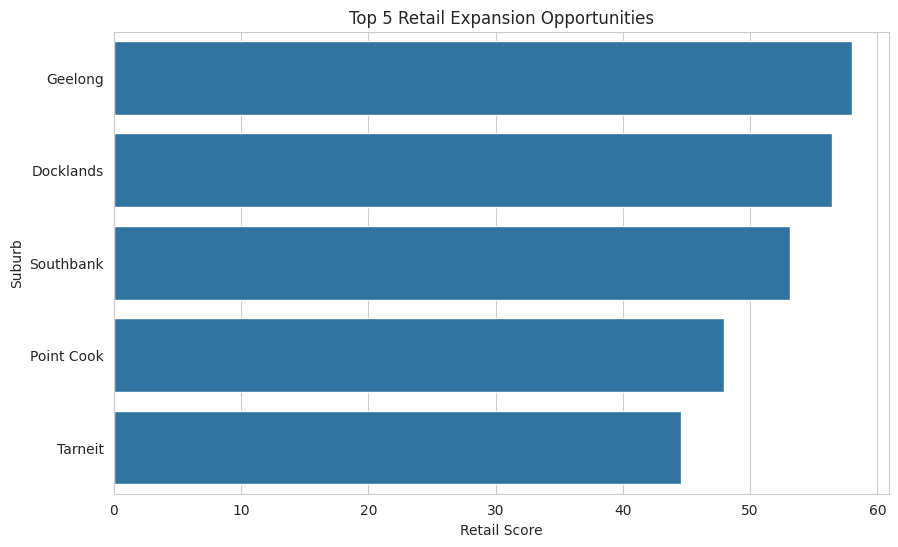

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

top5_retail = retail_rankings.head(5)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top5_retail,
    x="retail_score",
    y="suburb"
)

plt.title("Top 5 Retail Expansion Opportunities")

plt.xlabel("Retail Score")

plt.ylabel("Suburb")

plt.show()

Save Final Dataset

In [56]:
score_df.to_csv(
    "market_scope_industry.csv",
    index=False
)

print("Industry scoring completed successfully.")

Industry scoring completed successfully.


In [57]:
retail_rankings.head(5)



,suburb,retail_score
2,Geelong,58.003278
0,Docklands,56.447786
1,Southbank,53.120673
3,Point Cook,47.940812
5,Tarneit,44.558924


In [58]:
health_rankings.head(5)



,suburb,health_score
0,Docklands,86.222222
1,Southbank,79.766908
6,Richmond,58.158558
3,Point Cook,58.043133
7,Clayton,56.067978


In [59]:
telecom_rankings.head(5)

,suburb,telecom_score
0,Docklands,62.483709
1,Southbank,58.433911
2,Geelong,51.824017
5,Tarneit,51.249428
7,Clayton,49.698158


In [60]:
score_df.to_csv(
    "market_scope_industry.csv",
    index=False
)

print("Industry dataset saved successfully")

Industry dataset saved successfully


###################################################

In [61]:
import pandas as pd

score_df = pd.read_csv(
    "market_scope_industry.csv"
)

#Retail Recommendations

In [62]:
top_retail = score_df.sort_values(
    by="retail_score",
    ascending=False
).head(3)

top_retail[
    [
        "suburb",
        "retail_score",
        "risk_score",
        "key_strengths"
    ]
]

,suburb,retail_score,risk_score,key_strengths
2,Geelong,58.003278,10,Balanced Market Conditions
0,Docklands,56.447786,10,"Strong Purchasing Power, High Population Growt..."
1,Southbank,53.120673,10,"Strong Purchasing Power, High Population Growt..."


#Health Recommendations

In [63]:
top_health = score_df.sort_values(
    by="health_score",
    ascending=False
).head(3)

top_health[
    [
        "suburb",
        "health_score",
        "risk_score",
        "key_strengths"
    ]
]

,suburb,health_score,risk_score,key_strengths
0,Docklands,86.222222,10,"Strong Purchasing Power, High Population Growt..."
1,Southbank,79.766908,10,"Strong Purchasing Power, High Population Growt..."
6,Richmond,58.158558,10,"Strong Purchasing Power, Large Young Professio..."


#Telecom Recommendations

In [64]:
top_telecom = score_df.sort_values(
    by="telecom_score",
    ascending=False
).head(3)

top_telecom[
    [
        "suburb",
        "telecom_score",
        "risk_score",
        "key_strengths"
    ]
]

,suburb,telecom_score,risk_score,key_strengths
0,Docklands,62.483709,10,"Strong Purchasing Power, High Population Growt..."
1,Southbank,58.433911,10,"Strong Purchasing Power, High Population Growt..."
2,Geelong,51.824017,10,Balanced Market Conditions


In [65]:
import os

for file in os.listdir():
    print(file)

.config
market_scope_scored_data.csv
market_scope_final.csv
market_scope_industry.csv
market_scope_vic_data.csv
sample_data


In [66]:
score_df.columns.tolist()

['suburb',
 'population',
 'median_income',
 'age_20_39_percentage',
 'train_station_score',
 'competitor_count',
 'population_growth',
 'competitor_score',
 'opportunity_score',
 'risk_score',
 'recommendation',
 'key_strengths',
 'population_scaled',
 'income_scaled',
 'growth_scaled',
 'access_scaled',
 'young_scaled',
 'retail_score',
 'health_score',
 'telecom_score']

In [67]:
score_df.to_csv(
    "market_scope_industry.csv",
    index=False
)

In [68]:
from google.colab import files

files.download("market_scope_industry.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
print(score_df["opportunity_score"].describe())

count    15.000000
mean     43.890000
std      10.366533
min      27.630000
25%      37.350000
50%      45.390000
75%      49.850000
max      62.970000
Name: opportunity_score, dtype: float64


In [70]:
# Checking the original and scaled columns before using them in the dashboard

columns_to_check = [
    "suburb",
    "population",
    "population_scaled",
    "median_income",
    "income_scaled",
    "population_growth",
    "growth_scaled",
    "train_station_score",
    "access_scaled",
    "age_20_39_percentage",
    "young_scaled"
]

print(score_df[columns_to_check].head(15).to_string(index=False))

       suburb  population  population_scaled  median_income  income_scaled  population_growth  growth_scaled  train_station_score  access_scaled  age_20_39_percentage  young_scaled
    Docklands    0.007519           0.007519       1.000000       1.000000           0.611111       0.611111             1.000000       1.000000              1.000000      1.000000
    Southbank    0.018797           0.018797       0.916667       0.916667           0.555556       0.555556             1.000000       1.000000              0.869565      0.869565
      Geelong    1.000000           1.000000       0.250000       0.250000           0.111111       0.111111             0.857143       0.857143              0.217391      0.217391
   Point Cook    0.203008           0.203008       0.700000       0.700000           0.777778       0.777778             0.142857       0.142857              0.565217      0.565217
Glen Waverley    0.109023           0.109023       0.633333       0.633333           0.333333  

In [73]:
import pandas as pd

# Load the original master CSV dataset
master_df = pd.read_csv("market_scope_vic_data.csv")

# Check all column names
print(master_df.columns.tolist())

# Display the first 5 rows
display(master_df.head())

['suburb', 'population', 'median_income', 'age_20_39_percentage', 'train_station_score', 'competitor_count', 'population_growth']


,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth
0,Clayton,21000,92000,42,9,8,12
1,Glen Waverley,43000,108000,38,8,12,10
2,Box Hill,14000,98000,40,10,14,7
3,Burwood,16000,96000,39,7,9,8
4,Docklands,16000,130000,55,10,25,15


In [74]:
# ============================================================
# RESTORE ORIGINAL VALUES FOR DASHBOARD DISPLAY
# ============================================================
# The scoring dataset contains scaled values used for calculations.
# Here I bring back the original real-world values from my source
# dataset so the dashboard shows understandable numbers to users.
#
# This does NOT change the opportunity scores, industry scores,
# risk scores or rankings that were already calculated.
# ============================================================

# Columns containing the original real-world data
original_columns = [
    "suburb",
    "population",
    "median_income",
    "age_20_39_percentage",
    "train_station_score",
    "competitor_count",
    "population_growth"
]

# Create a copy of the final scored dataset
dashboard_df = score_df.copy()

# Remove the scaled versions that currently have the original
# column names. We will replace them with the real values.
dashboard_df = dashboard_df.drop(
    columns=[
        "population",
        "median_income",
        "age_20_39_percentage",
        "train_station_score",
        "competitor_count",
        "population_growth"
    ],
    errors="ignore"
)

# Match each suburb with its original real-world information
dashboard_df = dashboard_df.merge(
    master_df[original_columns],
    on="suburb",
    how="left"
)

# Arrange the important columns in a logical order
first_columns = [
    "suburb",
    "population",
    "median_income",
    "age_20_39_percentage",
    "train_station_score",
    "competitor_count",
    "population_growth",
    "opportunity_score",
    "risk_score",
    "recommendation",
    "key_strengths",
    "retail_score",
    "health_score",
    "telecom_score"
]

# Keep the important columns first, followed by any remaining columns
remaining_columns = [
    col for col in dashboard_df.columns
    if col not in first_columns
]

dashboard_df = dashboard_df[first_columns + remaining_columns]

# Check the final result
display(dashboard_df.head())

print("Dashboard dataset shape:", dashboard_df.shape)
print("Missing original values:")
print(
    dashboard_df[
        [
            "population",
            "median_income",
            "age_20_39_percentage",
            "train_station_score",
            "population_growth"
        ]
    ].isnull().sum()
)

,suburb,population,median_income,age_20_39_percentage,train_station_score,competitor_count,population_growth,opportunity_score,risk_score,recommendation,key_strengths,retail_score,health_score,telecom_score,competitor_score,population_scaled,income_scaled,growth_scaled,access_scaled,young_scaled
0,Docklands,16000,130000,55,10,25,15,62.97,10,Medium Priority,"Strong Purchasing Power, High Population Growt...",56.447786,86.222222,62.483709,4,0.007519,1.000000,0.611111,1.000000,1.000000
1,Southbank,19000,125000,52,10,20,14,59.01,10,Medium Priority,"Strong Purchasing Power, High Population Growt...",53.120673,79.766908,58.433911,4,0.018797,0.916667,0.555556,1.000000,0.869565
2,Geelong,280000,85000,37,9,16,6,53.32,10,Medium Priority,Balanced Market Conditions,58.003278,38.049862,51.824017,7,1.000000,0.250000,0.111111,0.857143,0.217391
3,Point Cook,68000,112000,45,4,5,18,52.02,6,High Priority,"Strong Purchasing Power, High Population Growt...",47.940812,58.043133,49.554974,8,0.203008,0.700000,0.777778,0.142857,0.565217
4,Glen Waverley,43000,108000,38,8,12,10,47.68,8,Medium Priority,Strong Purchasing Power,42.760325,53.307453,41.683557,10,0.109023,0.633333,0.333333,0.714286,0.260870


Dashboard dataset shape: (15, 20)
Missing original values:
population              0
median_income           0
age_20_39_percentage    0
train_station_score     0
population_growth       0
dtype: int64


In [75]:
# ============================================================
# EXPORT FINAL DATASET FOR THE STREAMLIT DASHBOARD
# ============================================================
# This saves the corrected dashboard dataset.
# It contains:
# - Original real-world suburb data
# - Opportunity and risk scores
# - Recommendations
# - Industry-specific scores
# - Scaled variables used in the scoring calculations
# ============================================================

dashboard_df.to_excel(
    "market_scope_industry1.xlsx",
    index=False
)

print("Dashboard dataset exported successfully!")
print("File name: market_scope_industry1.xlsx")
print("Total suburbs:", len(dashboard_df))

Dashboard dataset exported successfully!
File name: market_scope_industry1.xlsx
Total suburbs: 15
